
Geo Data Science with Python,
Prof. Susanna Werth, VT Geosciences

# Trend Estimation


This notebook is accompanied by the lecture L11 presentation slides.


---


In [1]:
# Import standard packages
import numpy as np
import matplotlib.pyplot as plt
import scipy
#import pandas as pd

# let's set a standard size for figures (a bit smaller, so they fit on the screen)
from matplotlib import rcParams
rcParams['figure.figsize'] = [4, 2]
rcParams.update({'font.size': 10})


---
# Synthetic Signal



In [2]:
# Create a signal: combination of annual and semi-annual sine waves + noise
fs2 = 365  # sampling frequency (1/year = 31.5 Mega Hz)
T2 = 25.5     # duration (years)
t2 = np.linspace(0, T2, int(fs2*T2))

# signal frequencies, amplitude, and noise components
f1, f2, f6 = 1, 1/3, 1/6     # frequencies of sine waves
f1_nonSt = np.linspace(1, 5, len(t2))

trendT_true = 0.3
trendA_true = 0.03
trendSig = trendT_true * t2    # trend
accelSig = trendA_true * t2*t2 # accelleration term
signal1  = 0.3 * np.sin( 2*np.pi * 2 * t2 )  # 0.5 year wave
signal2  = 1.0 * np.sin(2*np.pi  * 1 * t2)     # annual wave
signal3  = 0.8 * np.sin( 2*np.pi * 1/3 * t2 )  # 3 year wave
signal4  = 1.5 * np.sin( 2*np.pi * 1/5 * t2 )   # 5 year wave
signal5  = 1.5 * np.sin( 2*np.pi * 1/10 * t2 )   # 10 year wave
noise    = 0.5 * np.random.randn(len(t2))      # Noise

signalT_noise = trendSig + accelSig + signal1 + signal2 + signal3 + signal4 + noise


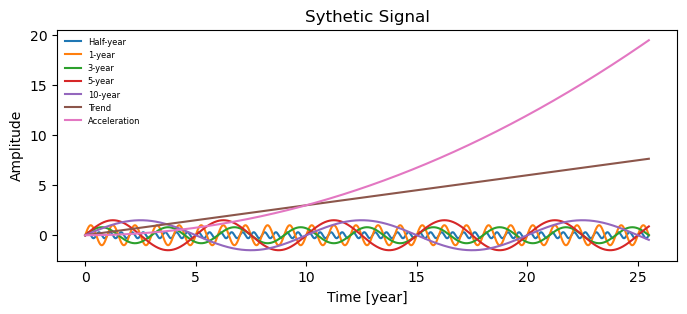

In [3]:
# Plot sythetic signals without noise
plt.figure(figsize=(8,3))
plt.plot(t2, signal1,  label='Half-year')
plt.plot(t2, signal2,  label='1-year')
plt.plot(t2, signal3,  label='3-year')
plt.plot(t2, signal4,  label='5-year')
plt.plot(t2, signal5,  label='10-year')
plt.plot(t2, trendSig,  label='Trend')
plt.plot(t2, accelSig,  label='Acceleration')
plt.title("Sythetic Signal")
plt.xlabel("Time [year]")
plt.ylabel("Amplitude")
#plt.xlim([-0.2,8.5])
plt.legend(loc='upper left',fontsize=6,frameon=False)
plt.show()


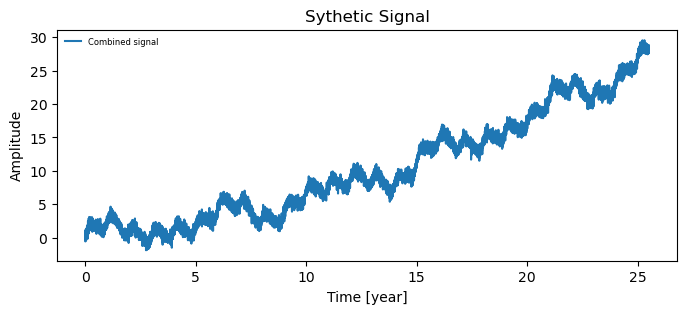

In [4]:
# Plot sythetic signals without noise
plt.figure(figsize=(8,3))
plt.plot(t2, signalT_noise,  label='Combined signal')
plt.title("Sythetic Signal")
plt.xlabel("Time [year]")
plt.ylabel("Amplitude")
#plt.xlim([-0.2,8.5])
plt.legend(loc='upper left',fontsize=6,frameon=False)
plt.show()


# Simple Regression Model

## scipy.signal.detrend()

In [5]:
from scipy import signal

# Linear Trend: best-fit straight-line trend using least squares (parametric)
detrendedLin = signal.detrend(signalT_noise, type='linear')
trendLin = signalT_noise - detrendedLin

## np.polyfit()

In [6]:
order = 2 # 1: linear trend; 2: accelleration
coeffs = np.polyfit(t2, signalT_noise, order)
model_poly = np.polyval(coeffs, t2)
model_trend = t2*coeffs[1]+coeffs[2]
model_accel = t2*t2*coeffs[0]+coeffs[2]
coeffs # coefficient order: first highest power, last constant term

array([0.03266888, 0.21244645, 0.58686977])

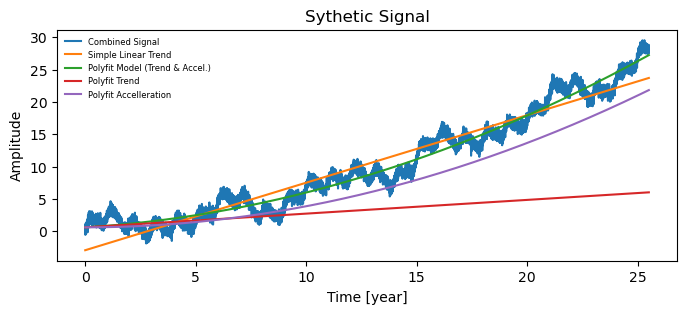

In [7]:
# Plot sythetic signals without noise
plt.figure(figsize=(8,3))
plt.plot(t2, signalT_noise,  label='Combined Signal')
plt.plot(t2, trendLin,  label='Simple Linear Trend')
plt.plot(t2, model_poly,  label='Polyfit Model (Trend & Accel.)')
plt.plot(t2, model_trend,  label='Polyfit Trend')
plt.plot(t2, model_accel,  label='Polyfit Accelleration')
plt.title("Sythetic Signal")
plt.xlabel("Time [year]")
plt.ylabel("Amplitude")
plt.legend(loc='upper left',fontsize=6,frameon=False)
plt.show()

In [8]:
print("Accuracy of trend estimates (sythetic, estimated, difference):")
print(" ")
slope, intercept = np.polyfit(t2, trendLin, 1)
print("Simple Trend (no acc.):",trendT_true, round(slope,2), round(trendT_true-slope,3))
print(" ")
print("Polyfit Linear Trend:  ",trendT_true, round(coeffs[1],2), round(trendT_true-coeffs[1],3))
print("Polyfit Acceleration:  ",trendA_true, round(coeffs[0],2), round(trendA_true-coeffs[0],3))



Accuracy of trend estimates (sythetic, estimated, difference):
 
Simple Trend (no acc.): 0.3 1.05 -0.746
 
Polyfit Linear Trend:   0.3 0.21 0.088
Polyfit Acceleration:   0.03 0.03 -0.003


### Takeaways:
- Simple linear detrend() cannot accomodate accelleration (or non-stationary signals) in the signal.
- Polyfit is more accurate if accelleration is present in the signal.
- If real non-stationary signals are present, adaptive approaches useful.

# Adaptive and Non-parametric Approaches

## LOESS

LOESS (LOWESS) is a nonparametric smoothing method that estimates a trend by fitting simple local regressions to small moving neighborhoods of the data. It produces a smooth curve that adapts to nonlinear and nonstationary patterns without assuming any specific functional form.

In [9]:
# LOESS / LOWESS detrending: nonparametric smoothing / trend-estimation method used widely in statistics, climate, hydrology, and geophysical time series.
# LOESS fits a smooth curve through noisy data without assuming any functional form (unlike linear or polynomial trends).
from statsmodels.nonparametric.smoothers_lowess import lowess
trendLOESS = lowess(signalT_noise, t2, frac=0.3, return_sorted=False)
    #frac: fraction of the total number of data points used to estimate each local fit.
    #return_sorted: controlls output format and sorting (False means same sorting as input and returns 1D array )


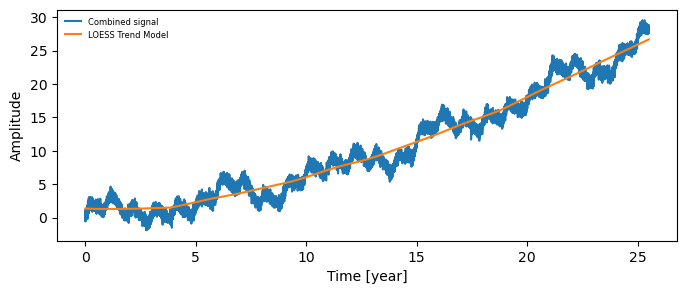

In [10]:
# Plot sythetic signals without noise
plt.figure(figsize=(8,3))
plt.plot(t2, signalT_noise,  label='Combined signal')
plt.plot(t2, trendLOESS,  label='LOESS Trend Model')
plt.xlabel("Time [year]")
plt.ylabel("Amplitude")
plt.legend(loc='upper left',fontsize=6,frameon=False)
plt.show()

## Empirical Mode Decomposition

Empirical Mode Decomposition (EMD) is a data-driven method that decomposes a nonstationary signal into a set of simple oscillatory components (IMFs) and a residual trend, without assuming any predefined basis functions. It adaptively separates fast, medium, and slow variations directly from the data.


In [11]:
# Install PyEMD if you don't have it yet
#! pip install EMD-signal


In [12]:
# -------------------------------------------------------
# 1. Get EMD Package
# -------------------------------------------------------
from PyEMD import EMD

In [13]:
# -------------------------------------------------------
# 2. Apply EMD
# -------------------------------------------------------
emd = EMD()
imfs = emd(signalT_noise)  # imfs.shape = (n_imfs, N)

print(f"Number of IMFs: {imfs.shape[0]}")

Number of IMFs: 10


In [14]:
# -------------------------------------------------------
# 3. Reconstruct the trend from the IMFs
# -------------------------------------------------------
# In classic EMD usage:
#   - High-frequency oscillations are in the first IMFs.
#   - The last IMF(s) and residual capture low-frequency trend.
#
# A common simple approach:
#   -> treat the LAST component as the "trend".
trend_emd = imfs[-1, :]

# You can also form a smoother trend by summing last few IMFs, e.g.:
#trend_emd = imfs[-1, :] + imfs[-2, :]



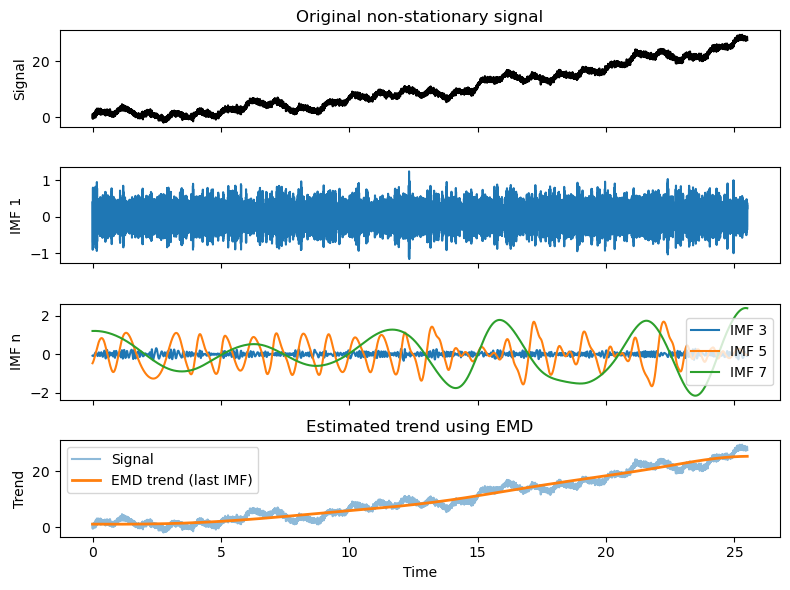

In [15]:
# -------------------------------------------------------
# 4. Plot results
# -------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

axes[0].plot(t2, signalT_noise, label="Signal", color="k")
axes[0].set_ylabel("Signal")
axes[0].set_title("Original non-stationary signal")

# Show a few IMFs
axes[1].plot(t2, imfs[0, :], label="IMF 1")
axes[1].set_ylabel("IMF 1")

if imfs.shape[0] > 1:
    axes[2].plot(t2, imfs[4, :], label="IMF 3")
    axes[2].plot(t2, imfs[6, :], label="IMF 5")
    axes[2].plot(t2, imfs[8, :], label="IMF 7")
    axes[2].set_ylabel("IMF n")
    axes[2].legend()

# Trend
axes[3].plot(t2, signalT_noise, alpha=0.5, label="Signal")
axes[3].plot(t2, trend_emd, linewidth=2, label="EMD trend (last IMF)")
axes[3].set_xlabel("Time")
axes[3].set_ylabel("Trend")
axes[3].legend()
axes[3].set_title("Estimated trend using EMD")

plt.tight_layout()
plt.show()

## Test accuracy of linear trends after LOESS or EMD decomposition

In [16]:
order = 2 # 1: linear trend; 2: accelleration

# after LOESS
coeffs_loess = np.polyfit(t2, trendLOESS, order)
model_loess = np.polyval(coeffs_loess, t2)

# after EMD
coeffs_emd = np.polyfit(t2, trend_emd, order)
model_emd = np.polyval(coeffs_emd, t2)


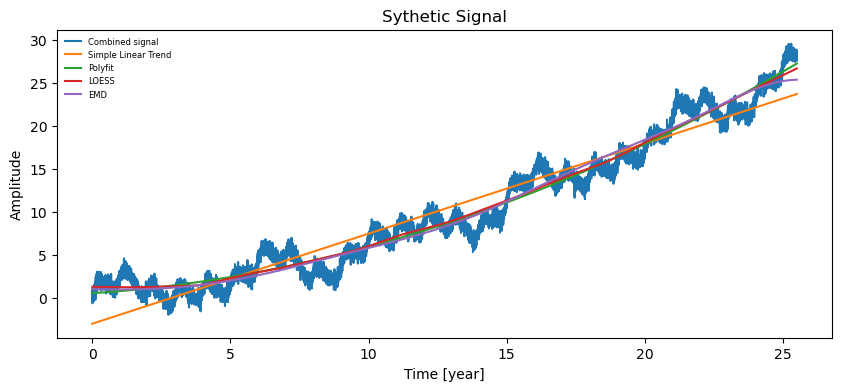

In [17]:
# Plot sythetic signals without noise
plt.figure(figsize=(10,4))
plt.plot(t2, signalT_noise,  label='Combined signal')
plt.plot(t2, trendLin,  label='Simple Linear Trend')
plt.plot(t2, model_poly,  label='Polyfit')
plt.plot(t2, trendLOESS,  label='LOESS')
plt.plot(t2, trend_emd,  label='EMD')
plt.title("Sythetic Signal")
plt.xlabel("Time [year]")
plt.ylabel("Amplitude")
plt.legend(loc='upper left',fontsize=6,frameon=False)
plt.show()

In [18]:
print("Accuracy of trend estimates (estimated, difference):")
print(" ")
print("Synthetic Trend:        ", trendT_true)
print("Linear Trend estimate:  ", round(slope,2),       round(trendT_true-slope,3))
print("Trend estimate w. Polyf:", round(coeffs[1],2),       round(trendT_true-coeffs[1],3))
print("Trend estimate w. Loess:", round(coeffs_loess[1],2), round(trendT_true-coeffs_loess[1],3))
print("Trend estimate w. EMD:  ", round(coeffs_emd[1],2),   round(trendT_true-coeffs_emd[1],3))
print(" ")
print("Synthetic Accel.:        ", trendA_true)
print("Accel. estimate w. Polyf:", round(coeffs[0],2),       round(trendA_true-coeffs[0],3))
print("Accel. estimate w. Loess:", round(coeffs_loess[0],2), round(trendA_true-coeffs_loess[0],3))
print("Accel. estimate w. EMD:  ", round(coeffs_emd[0],2),   round(trendA_true-coeffs_emd[0],3))


Accuracy of trend estimates (estimated, difference):
 
Synthetic Trend:         0.3
Linear Trend estimate:   1.05 -0.746
Trend estimate w. Polyf: 0.21 0.088
Trend estimate w. Loess: 0.23 0.069
Trend estimate w. EMD:   0.27 0.034
 
Synthetic Accel.:         0.03
Accel. estimate w. Polyf: 0.03 -0.003
Accel. estimate w. Loess: 0.03 -0.002
Accel. estimate w. EMD:   0.03 -0.001


Note: If you rerun the code, EMD and loess are not always more accurate, because this also depends on noise, adaptive approaches and exact oscillations in the dataset. However, if you would do a sampling test (run 1000s of samples), on average EMD and LOESS would provide more accurate trend estimates.


### Takeaways:
- If your signal contains oscillations, trend estimation might be instable. (It would vary also with the length of the observation, especially if oscillations are present in the signal.)
- Removing oscillating signals before estimating linear trends is advised and will result in more accurate estimates.
- LOESS and EMD are two approaches working well for non-stationary signals. Alternatively, if your signal is relatively stationary and you know the modes present, you can also fit a harmonic regression model.